# Week 1 — Logistic Regression and Gradient Descent

This notebook works through all six parts. We derive the losses and gradients,
implement gradient descent from scratch, and run the full sequence of
experiments on the synthetic 2D dataset and the breast-cancer dataset.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=6, suppress=True)
%matplotlib inline

## Core implementations

In [ ]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    ...
    return out

def ce_loss(w, b, X, y):
    z = X @ w + b
    # log(1+exp(z)) - y*z   is the stable form of -[y log p + (1-y) log(1-p)]
    return float(np.mean(np.logaddexp(0.0, z) - y * z))

def ce_grad(w, b, X, y):
    ...

def mse_loss(w, b, X, y):
    p = sigmoid(X @ w + b)
    return float(np.mean((p - y) ** 2))

def mse_grad(w, b, X, y):
    ...

def gradient_descent(X, y, loss_fn, grad_fn, w0, b0, lr, n_iter):
    w = np.array(w0, dtype=float).copy()
    b = float(b0)
    ws, bs = [w.copy()], [b]
    losses = [loss_fn(w, b, X, y)]
    gnorms = []
    for _ in range(n_iter):
        gw, gb = grad_fn(w, b, X, y)
        gnorms.append(float(np.sqrt(np.sum(gw*gw) + gb*gb)))
        w = ...
        b = ...
        ws.append(w.copy()); bs.append(b)
        losses.append(loss_fn(w, b, X, y))
    gw, gb = grad_fn(w, b, X, y)
    gnorms.append(float(np.sqrt(np.sum(gw*gw) + gb*gb)))
    return w, b, {
        "w": np.array(ws), "b": np.array(bs),
        "loss": np.array(losses), "grad_norm": np.array(gnorms),
    }

def accuracy(w, b, X, y):
    return float(np.mean((sigmoid(X @ w + b) >= 0.5).astype(int) == y))

## Data (Parts 1–5)

In [ ]:
X, y = make_classification(
    n_samples=400, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.3, random_state=0,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)
print(f"train: {X_tr.shape}, test: {X_te.shape}")

train: (300, 2), test: (100, 2)


## Part 1 — Cross-entropy, small initialization

In [ ]:
w0_small = np.array([0.01, -0.01])
b0 = 0.0
w1, b1, hist1 = gradient_descent(X_tr, y_tr, ce_loss, ce_grad,
                                  w0_small, b0, lr=0.1, n_iter=2000)
print(f"final w          = {w1}")
print(f"final b          = {b1:.6f}")
print(f"train accuracy   = {accuracy(w1, b1, X_tr, y_tr):.4f}")
print(f"test  accuracy   = {accuracy(w1, b1, X_te, y_te):.4f}")
print(f"loss @ iter 0    = {hist1['loss'][0]:.6f}")
print(f"loss @ iter 100  = {hist1['loss'][100]:.6f}")
print(f"loss @ iter 2000 = {hist1['loss'][2000]:.6f}")

final w          = [-1.216318  2.929677]
final b          = 2.370431
train accuracy   = 0.9300
test  accuracy   = 0.8900
loss @ iter 0    = 0.699814
loss @ iter 100  = 0.262572
loss @ iter 2000 = 0.197832


## Part 2 — MSE, and both losses from $(4, -4)$

In [ ]:
# MSE with the small init
_, _, hist_mse_s = gradient_descent(X_tr, y_tr, mse_loss, mse_grad,
                                    w0_small, b0, lr=0.1, n_iter=2000)

# Both losses with big init
w0_big = np.array([4.0, -4.0])
_, _, hist_ce_b  = gradient_descent(X_tr, y_tr, ce_loss,  ce_grad,
                                    w0_big, b0, lr=0.1, n_iter=2000)
_, _, hist_mse_b = gradient_descent(X_tr, y_tr, mse_loss, mse_grad,
                                    w0_big, b0, lr=0.1, n_iter=2000)

print(f"MSE grad norm @ iter 0   (from (4,-4)) = {hist_mse_b['grad_norm'][0]:.6e}")
print(f"MSE grad norm @ iter 100 (from (4,-4)) = {hist_mse_b['grad_norm'][100]:.6e}")

MSE grad norm @ iter 0   (from (4,-4)) = 8.894045e-02
MSE grad norm @ iter 100 (from (4,-4)) = 1.028034e-01


In [ ]:
def plot_part2(hist_ce, hist_mse, title):
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes[0,0].plot(hist_ce['loss']);  axes[0,0].set_title('CE loss');  axes[0,0].set_xlabel('iter')
    axes[0,1].plot(hist_mse['loss']); axes[0,1].set_title('MSE loss'); axes[0,1].set_xlabel('iter')
    axes[1,0].plot(hist_ce['grad_norm']);  axes[1,0].set_title('CE grad norm');
    axes[1,0].set_yscale('log'); axes[1,0].set_xlabel('iter')
    axes[1,1].plot(hist_mse['grad_norm']); axes[1,1].set_title('MSE grad norm');
    axes[1,1].set_yscale('log'); axes[1,1].set_xlabel('iter')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_part2(hist1,     hist_mse_s, 'Init = (0.01, -0.01)')
plot_part2(hist_ce_b, hist_mse_b, 'Init = (4, -4)')

## Part 3 — Feature scaling and learning rate

In [ ]:
X_tr_rs = X_tr.copy()
X_tr_rs[.... # Add the scaling here

std_before = ...
std_after  = ...
print(f"std(feature0)/std(feature1) before = {std_before:.4f}")
print(f"std(feature0)/std(feature1) after  = {std_after:.4f}")
print(f"ratio of ratios                    = {std_after/std_before:.2f}")

std(feature0)/std(feature1) before = 0.4858
std(feature0)/std(feature1) after  = 48.5823
ratio of ratios                    = 100.00


In [ ]:
lrs = [0.1, 0.01, 0.001, 0.0001]
part3_hist = {}
for tag, data in [('orig', X_tr), ('rescaled', X_tr_rs)]:
    for lr in lrs:
        _, _, h = gradient_descent(data, y_tr, ce_loss, ce_grad,
                                   w0_small, 0.0, lr=lr, n_iter=2000)
        part3_hist[(tag, lr)] = h

fig, ax = plt.subplots(figsize=(9, 6))
colors = {0.1:'C0', 0.01:'C1', 0.001:'C2', 0.0001:'C3'}
styles = {'orig':'-', 'rescaled':'--'}
for (tag, lr), h in part3_hist.items():
    ax.plot(h['loss'], color=colors[lr], linestyle=styles[tag],
            label=f'{tag}, lr={lr}')
ax.set_xlabel('iteration'); ax.set_ylabel('CE loss')
ax.set_yscale('log')
ax.legend(ncol=2, fontsize=8)
ax.set_title('CE loss, original vs rescaled, 4 learning rates')
plt.tight_layout(); plt.show()

print('\nFinal losses on rescaled data:')
for lr in lrs:
    final = part3_hist[('rescaled', lr)]['loss'][-1]
    print(f'  lr={lr}:  final loss = {final:.4f}')

## Part 4 — Loss landscape with four trajectories

We fix $b$ at its Part 1 value, plot CE loss as a function of $(w_0, w_1)$,
and overlay four gradient-descent paths chosen to show the main regimes.


In [ ]:
b_fixed = b1

# build a rectangle around the Part 1 solution
w_opt = w1
pad = 4.0
w0_grid = np.linspace(w_opt[0] - pad, w_opt[0] + pad, 120)
w1_grid = np.linspace(w_opt[1] - pad, w_opt[1] + pad, 120)
W0, W1 = np.meshgrid(w0_grid, w1_grid)

# vectorized loss evaluation
Wflat = ...         # (G, 2)
Z = ....                         # (G, N)
L = np.mean(...., axis=1).reshape(W0.shape)

# four trajectories. Play around the values here to induce different effects
traj_specs = [
    ("clean:  (...), lr=...",   ,
    ("zigzag: (....), lr=...",  ,
    ("diverge: (....), lr=...", ,
    ("Part 1 path",              ,
]
trajs = []
for label, w0, lr, n in traj_specs:
    _, _, h = gradient_descent(X_tr, y_tr, ce_loss, ce_grad,
                               w0, b_fixed, lr=lr, n_iter=n)
    trajs.append((label, h['w']))

fig, ax = plt.subplots(figsize=(9, 8))
levels = np.logspace(np.log10(max(L.min(), 1e-3)), np.log10(L.max()), 20)
cs = ax.contourf(W0, W1, L, levels=levels, cmap='viridis', alpha=0.85)
ax.contour(W0, W1, L, levels=levels, colors='white', linewidths=0.4, alpha=0.5)
plt.colorbar(cs, ax=ax, label='CE loss (log-spaced levels)')

path_colors = ['tab:red', 'tab:orange', 'tab:pink', 'white']
for (label, W), c in zip(trajs, path_colors):
    ax.plot(W[:,0], W[:,1], '-', color=c, lw=1.6, label=label)
    ax.plot(W[0,0], W[0,1], 'o', color=c, mec='black', ms=7)

ax.plot(w_opt[0], w_opt[1], '*', color='yellow', mec='black', ms=16, label='Part 1 min')
ax.set_xlabel('$w_0$'); ax.set_ylabel('$w_1$')
ax.set_title('CE loss landscape (b fixed) with 4 GD paths')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

## Part 5 — One-class training

In [ ]:
mask = ...
X_one = X_tr[mask]
y_one = y_tr[mask]
print(f'Kept {len(X_one)} samples (all label 1)')

w5, b5, hist5 = gradient_descent(X_one, y_one, ce_loss, ce_grad,
                                 np.zeros(2), 0.0, lr=0.05, n_iter=5000)
wnorm =....

print(f'||w|| @ iter  100 = {wnorm[100]:.4f}')
print(f'||w|| @ iter 1000 = {wnorm[1000]:.4f}')
print(f'||w|| @ iter 5000 = {wnorm[5000]:.4f}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist5['loss'])
axes[0].set_title('CE loss (one-class)'); axes[0].set_xlabel('iter')

axes[1].plot(wnorm)
axes[1].set_yscale('log')
axes[1].set_title('||w||  (log y)'); axes[1].set_xlabel('iter')

axes[2].plot(hist5['b'])
axes[2].set_title('bias'); axes[2].set_xlabel('iter')
plt.tight_layout(); plt.show()

In [ ]:
# Side-by-side: Part 1 classifier on full data vs one-class classifier on full test data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def draw_decision_bg(ax, w, b, X_plot, y_plot, title):
    x0 = np.linspace(X_plot[:,0].min()-0.5, X_plot[:,0].max()+0.5, 200)
    x1 = np.linspace(X_plot[:,1].min()-0.5, X_plot[:,1].max()+0.5, 200)
    XX, YY = np.meshgrid(x0, x1)
    G = np.stack([XX.ravel(), YY.ravel()], axis=1)
    P =  # Compute Sigmoid for all the points on the grid now. Use the Stacked G from the previous line
    ax.contourf(XX, YY, P, levels=20, cmap='RdBu_r', alpha=0.5)
    ax.contour(XX, YY, P, levels=[0.5], colors='k', linewidths=1.5)
    for c, col, lab in [(0, 'tab:blue', 'class 0'), (1, 'tab:red', 'class 1')]:
        ax.scatter(X_plot[y_plot==c, 0], X_plot[y_plot==c, 1],
                   c=col, edgecolor='k', s=28, label=lab)
    ax.set_title(title); ax.set_xlabel('$x_0$'); ax.set_ylabel('$x_1$')
    ax.legend(loc='best')

draw_decision_bg(axes[0], w1, b1, X_te, y_te, 'Part 1 classifier on test set')

draw_decision_bg(axes[1], w5, b5, X_te, y_te,
                 'One-class classifier on full test set')
# draw weight vector as arrow from origin, scaled to be visible
scale = 0.7 * max(np.abs(axes[1].get_xlim()).max(), np.abs(axes[1].get_ylim()).max()) / max(np.linalg.norm(w5), 1e-9)
axes[1].annotate('', xy=(w5[0]*scale, w5[1]*scale), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=2))
axes[1].plot(0, 0, 'ko', ms=5)
axes[1].text(w5[0]*scale*0.55, w5[1]*scale*0.55 + 0.2, '$w$', fontsize=14)
plt.tight_layout(); plt.show()

## Part 6 — Breast cancer: standardized vs not

In [ ]:
bc = load_breast_cancer()
Xb, yb = bc.data, bc.target
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25, random_state=0)

mu = Xb_tr.mean(axis=0)
sd = Xb_tr.std(axis=0)
Xb_tr_s = ..
Xb_te_s = ..
# feature scale spread
feat_stds = Xb_tr.std(axis=0)
print(f'Feature std: min={feat_stds.min():.4f}  max={feat_stds.max():.4f}  '
      f'ratio={feat_stds.max()/feat_stds.min():.1f}')

Feature std: min=0.0026  max=585.6644  ratio=222922.1


In [ ]:
print(f'\nStandardized reaches loss {target:.4f} by iter {std_iters_to_target}')
print(f'Unstandardized reaches that loss within 2000 iters? {unstd_ever}')

Standardized   : train acc = 0.9906, test acc = 0.9720, final train loss = 0.0532
Unstandardized : train acc = 0.9085, test acc = 0.8951, final train loss = 0.3743

Standardized reaches loss 0.0532 by iter 2000
Unstandardized reaches that loss within 2000 iters? False


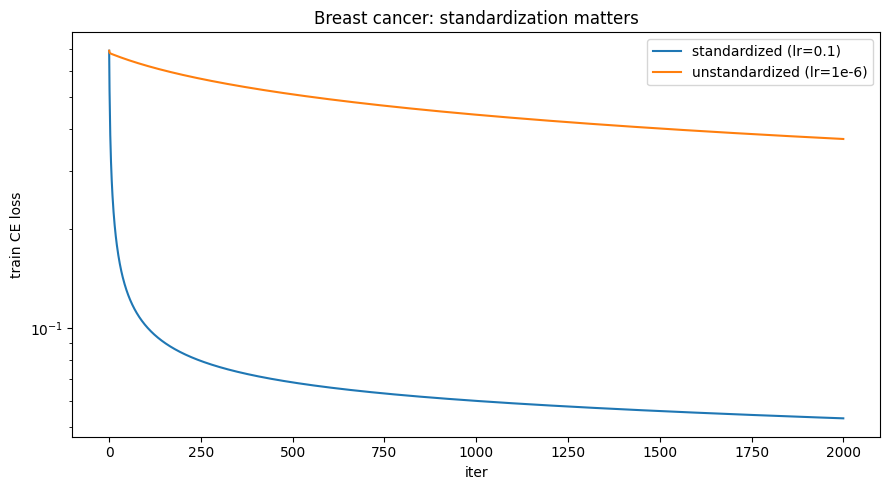

In [ ]:
#Try producing a similar plot to this.